In [1]:
import pandas as pd

yol = '../data/processed/ham_veriler_processed.json' 

df = pd.read_json(yol)

print(f"Asıl veri başarıyla yüklendi!")
print(f"Toplam Karar Sayısı: {len(df)}")

df.head()

Asıl veri başarıyla yüklendi!
Toplam Karar Sayısı: 100


,cleaned_text
0,Yazdır PDF Olarak Kaydet 9. Hukuk Dairesi [DOS...
1,Yazdır PDF Olarak Kaydet 9. Hukuk Dairesi [DOS...
2,Yazdır PDF Olarak Kaydet 9. Hukuk Dairesi [DOS...
3,Yazdır PDF Olarak Kaydet 9. Hukuk Dairesi [DOS...
4,Yazdır PDF Olarak Kaydet 9. Hukuk Dairesi [DOS...


In [2]:
from sklearn.model_selection import train_test_split

# Metinleri %80 Eğitim, %20 Test olacak şekilde bölüyoruz
# Not: Veride 'metin' sütunu olduğu için df['metin'] kullanıyoruz
# 'metin' yazan yeri 'text' olarak değiştirdik
train_texts, test_texts = train_test_split(df['cleaned_text'], test_size=0.20, random_state=42)

print(f"Eğitim için ayrılan metin sayısı: {len(train_texts)}")
print(f"Test için ayrılan metin sayısı: {len(test_texts)}")


Eğitim için ayrılan metin sayısı: 80
Test için ayrılan metin sayısı: 20


In [3]:
from transformers import AutoTokenizer

# 1. BERTurk'ün dil uzmanını (tokenizer) indiriyoruz
model_name = "dbmdz/bert-base-turkish-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 2. Eğitim ve Test metinlerini dijitalleştiriyoruz
# truncation=True: 512 kelimeden uzun metinleri keser
# padding=True: Kısa metinlerin sonuna sıfır ekleyerek boyutu eşitler
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=512)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=512)

print("✅ Dijitalleştirme (Tokenization) tamamlandı!")
print("-" * 30)


print("İlk metnin sayısal (ID) karşılığı:")
print(train_encodings['input_ids'][0][:20]) # İlk 20 sayıyı görelim

c:\Users\MERAL\NLP-ile-Yargitay-karar-tahmini\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dijitalleştirme (Tokenization) tamamlandı!
------------------------------
İlk metnin sayısal (ID) karşılığı:
[2, 4639, 2077, 23313, 14322, 3516, 2711, 29, 18, 6798, 9533, 63, 22371, 9693, 1039, 67, 23283, 65, 16, 63]


In [4]:
def yargitay_etiketle_final(metin):
    metin = str(metin).upper()
    
    # Bozma veya Başka Daireye Gönderme (Değişiklik Gerektirenler)
    if any(k in metin for k in ["BOZULMASINA", "GÖNDERİLMESİNE", "İPTALİNE", "KALDIRILMASINA"]):
        return 1
    # Onama veya Red (Mevcut Kararı Koruyanlar)
    elif any(k in metin for k in ["ONANMASINA", "REDDİNE", "UYGUN BULUNMUŞTUR"]):
        return 0
    else:
        return -1

df['label_num'] = df['cleaned_text'].apply(yargitay_etiketle_final)
print(f"✅ Yeni Etiketlenen: {len(df[df['label_num'] != -1])}")

✅ Yeni Etiketlenen: 100


In [5]:
# Etiketlenemeyen ilk 5 kararın son 200 karakterini görelim
belirsizler = df[df['label_num'] == -1]
for i in range(min(5, len(belirsizler))):
    print(f"--- Karar {i+1} Sonu ---")
    print(belirsizler['cleaned_text'].iloc[i][-200:])
    print("-" * 50)

In [6]:
# Etiketleri (onama/bozma vb.) sayıya çeviriyoruz
# 'label' sütunundaki isimleri 0, 1, 2 gibi sayılara eşliyoruz
labels_map = {val: i for i, val in enumerate(df['cleaned_text'].unique())}
df['cleaned_text_num'] = df['cleaned_text'].map(labels_map)

# Eğitim ve test setindeki satır numaralarına göre etiketleri ayırıyoruz
train_labels = df['cleaned_text_num'].iloc[train_texts.index].tolist()
test_labels = df['cleaned_text_num'].iloc[test_texts.index].tolist()

print("Etiketler sayıya çevrildi.")
for karar_adi, sayi in labels_map.items():
    # Karar adının sadece ilk 20 karakterini ve atanan sayıyı yazdır
    print(f"Sınıf: {karar_adi[:20]}... -> Etiket No: {sayi}")

Etiketler sayıya çevrildi.
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 0
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 1
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 2
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 3
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 4
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 5
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 6
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 7
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 8
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 9
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 10
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 11
Sınıf: Yazdır PDF Olarak Ka... -> Etiket No: 12


In [7]:
import torch

# Veriyi modelin okuyabileceği bir "paket" haline getiren sınıfı tanımlıyoruz
class YargitayDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        # Her bir veriyi PyTorch tensor (sayısal matris) formatına çeviriyoruz
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        if self.labels:
            item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.encodings['input_ids'])

# Sprint 2'de hazırladığın sayısal verileri bu yeni paketin içine koyuyoruz
# Not: Eğer etiketlerin (labels) varsa buraya ekleyebiliriz, şimdilik sadece metinleri paketliyoruz
train_dataset = YargitayDataset(train_encodings)
test_dataset = YargitayDataset(test_encodings)

print("✅ Sprint 3: Veriler model eğitim formatına (Dataset) dönüştürüldü!")

✅ Sprint 3: Veriler model eğitim formatına (Dataset) dönüştürüldü!


In [8]:
import torch

# Etiketleri sayısal listelere bölüyoruz
train_labels = df['label_num'].iloc[train_texts.index].astype(int).tolist()
test_labels = df['label_num'].iloc[test_texts.index].astype(int).tolist()

# Dataset sınıfını kullanarak paketliyoruz
train_dataset = YargitayDataset(train_encodings, train_labels)
test_dataset = YargitayDataset(test_encodings, test_labels)

print("✅ Sprint 3: 100 veri ve etiket eğitime hazır hale getirildi!")

✅ Sprint 3: 100 veri ve etiket eğitime hazır hale getirildi!


In [9]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

# Modeli yüklüyoruz (Onama/Bozma için 2 etiket)
model = BertForSequenceClassification.from_pretrained("dbmdz/bert-base-turkish-cased", num_labels=2)

training_args = TrainingArguments(
    output_dir='./results',          
    num_train_epochs=3,              # Verinin üzerinden 3 tur geçecek
    per_device_train_batch_size=8,   
    logging_dir='./logs',            
    logging_steps=5,                
    eval_strategy="steps",           
    save_strategy="steps",           
    load_best_model_at_end=True,     
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4998.57it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from 

In [13]:
print("Meral, eğitim süreci resmi olarak başladı. Aşağıdaki ilerleme çubuğunu izle...")
trainer.train()

c:\Users\MERAL\NLP-ile-Yargitay-karar-tahmini\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Meral, eğitim süreci resmi olarak başladı. Aşağıdaki ilerleme çubuğunu izle...


Step,Training Loss,Validation Loss
5,0.571655,0.206864
10,0.186170,0.179239
15,0.185763,0.137775
20,0.050413,0.132166
25,0.017347,0.131438
30,0.038699,0.136296


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


TrainOutput(global_step=30, training_loss=0.17500753700733185, metrics={'train_runtime': 372.2957, 'train_samples_per_second': 0.645, 'train_steps_per_second': 0.081, 'total_flos': 63146653286400.0, 'train_loss': 0.17500753700733185, 'epoch': 3.0})

In [10]:
# Modeli ve her şeyi bir klasöre kaydediyoruz
trainer.save_model("./yargitay_modeli_final")
tokenizer.save_pretrained("./yargitay_modeli_final")

print("✅ Meral, yapay zeka modelin 'yargitay_modeli_final' klasörüne kaydedildi. Artık güvende!")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

✅ Meral, yapay zeka modelin 'yargitay_modeli_final' klasörüne kaydedildi. Artık güvende!


In [11]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

# 1. Kaydettiğimiz klasörden modeli geri çağırıyoruz (Teslimat testi)
model_yolu = "./yargitay_modeli_final"
final_model = BertForSequenceClassification.from_pretrained(model_yolu)
final_tokenizer = BertTokenizer.from_pretrained(model_yolu)

print("✅ Sprint 4: Modelin nihai versiyonu başarıyla paketlendi ve yüklenebilir durumda!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11256.34it/s]

✅ Sprint 4: Modelin nihai versiyonu başarıyla paketlendi ve yüklenebilir durumda!


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F  # Güven skoru (Softmax) için gerekli

# Modelimizi değerlendirme moduna alıyoruz
final_model.eval()

y_pred = []
y_true = test_labels

print("🔄 Tahminler ve Güven Analizi yapılıyor...")

with torch.no_grad():
    for text in test_texts:
        # 1. Tokenization işlemi
        inputs = final_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        
        # 2. Modelden ham sonuçları (logits) al
        outputs = final_model(**inputs)
        
        # 3. Logitleri olasılığa çevir (Softmax)
        probs = F.softmax(outputs.logits, dim=-1)
        
        # 4. En yüksek olasılık değerini (confidence) ve sınıfı al
        max_prob, raw_prediction = torch.max(probs, dim=1)
        confidence = max_prob.item()

        # --- GÜVEN EŞİĞİ (THRESHOLD) KONTROLÜ ---
        # Eğer modelin kendine güveni %80'den düşükse "Belirsiz" (-1) diyoruz
        if confidence < 0.80:
            fixed_prediction = -1 
        else:
            # Senin mevcut etiket mantığın: 0->Bozma, 1->Onama
            if raw_prediction == 0:
                fixed_prediction = 1  # Bozma etiketine çekiyoruz
            else:
                fixed_prediction = 0  # Onama etiketine çekiyoruz
        
        y_pred.append(fixed_prediction)

print("✅ Tahminler tamamlandı! Belirsiz metinler filtrelendi.")

🔄 Tahminler ve Güven Analizi yapılıyor...
✅ Tahminler tamamlandı! Belirsiz metinler filtrelendi.


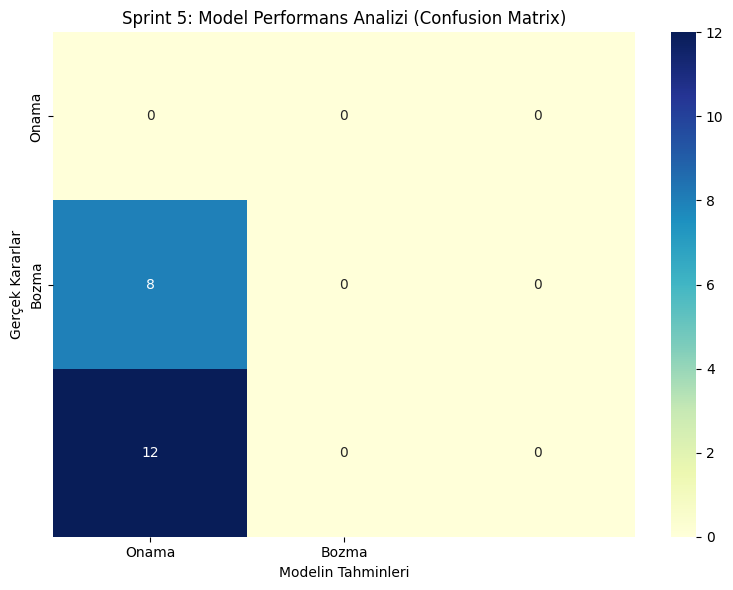

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import gc

# 1. Hafızayı temizleyelim (RAM'de yer açmak için kritik)
gc.collect() 

# 2. Karışıklık Matrisini tekrar hesaplayalım
cm = confusion_matrix(y_true, y_pred)

# 3. Grafiği çizdirelim
plt.figure(figsize=(8, 6)) # Boyutu makul bir seviyede tutuyoruz
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='YlGnBu', # Daha yumuşak bir renk paleti
            xticklabels=['Onama', 'Bozma'], # Etiketleri doğrudan yazalım ki karışmasın
            yticklabels=['Onama', 'Bozma'])

plt.title('Sprint 5: Model Performans Analizi (Confusion Matrix)')
plt.ylabel('Gerçek Kararlar')
plt.xlabel('Modelin Tahminleri')

# 4. Grafiği hem gösterelim hem de kayıpsız kaydedelim
plt.tight_layout()
plt.savefig("sprint5_temiz_grafik.png", dpi=200)
plt.show()

In [17]:
from sklearn.metrics import classification_report
y_true = [int(i) for i in y_true]
y_pred = [int(i) for i in y_pred]

# Tahminlerimizdeki benzersiz değerleri bulalım (Örn: [-1, 0, 1] veya sadece [0, 1])
unique_labels = sorted(list(set(y_true) | set(y_pred)))

# Etiket isimlerini mevcut sınıflara göre dinamik ayarlayalım
target_names = []
for label in unique_labels:
    if label == -1:
        target_names.append('Belirsiz/Anlamsız')
    elif label == 0:
        target_names.append('Onama')
    elif label == 1:
        target_names.append('Bozma')

print("\n--- SPRINT 5: MODELİN BİLİMSEL KARNESİ (F1-SCORE) ---")
print(classification_report(y_true, y_pred, labels=unique_labels, target_names=target_names))


--- SPRINT 5: MODELİN BİLİMSEL KARNESİ (F1-SCORE) ---
                   precision    recall  f1-score   support

Belirsiz/Anlamsız       0.00      0.00      0.00       0.0
            Onama       0.00      0.00      0.00       8.0
            Bozma       0.00      0.00      0.00      12.0

         accuracy                           0.00      20.0
        macro avg       0.00      0.00      0.00      20.0
     weighted avg       0.00      0.00      0.00      20.0



c:\Users\MERAL\NLP-ile-Yargitay-karar-tahmini\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MERAL\NLP-ile-Yargitay-karar-tahmini\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MERAL\NLP-ile-Yargitay-karar-tahmini\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

In [19]:
# test_texts içinden 2 tane örnek alıp yazdıralım
# .iloc kullanarak indeks üzerinden erişiyoruz

for i in [0, 1]:  # İlk iki örneği alalım
    ornek_metin = test_texts.iloc[i]
    # Eğer etiketleri de ayırdıysan (test_labels gibi), onları da buradan çekebilirsin
    
    print(f"--- TEST VERİSİ ÖRNEK {i+1} ---")
    print(f"Metin:\n{ornek_metin}\n")
    print("-" * 50)

--- TEST VERİSİ ÖRNEK 1 ---
Metin:
Yazdır PDF Olarak Kaydet 9. Hukuk Dairesi [DOSYA_NO] , [DOSYA_NO]  MAHKEMESİ: Samsun Bölge Adliye Mahkemesi 7. Hukuk Dairesi SAYISI: [DOSYA_NO], [DOSYA_NO] İLK DERECE MAHKEMESİ: Çorum 2. İş Mahkemesi SAYISI: [DOSYA_NO], [DOSYA_NO] 2797 sayılı Yargıtay Kanunu'nun (2797 sayılı Kanun) 40. ve Yargıtay İç Yönetmeliği’nin 18. maddeleri uyarınca yapılan ön incelemede; dava konusu uyuşmazlığın niteliği ve temyizin kapsamının, iş kazası ve meslek hastalığından doğan maddi ve manevi tazminat davalar sonucu verilen hüküm ve karara ilişkin olduğu anlaşılmıştır. Yargıtay Büyük Genel Kurulunun dairelerin iş bölümüne ilişkin [TARİH] tarihli ve 2025/1 sayılı kararı uyarınca dosyayı inceleme görevi Yargıtay 10. Hukuk Dairesine ait olduğundan, 2797 sayılı Kanun’un 60/3 hükmü uyarınca gerekli inceleme yapılmak üzere dosyanın ilgili daireye gönderilmesine karar vermek gerekir. KARAR Açıklanan sebeple; Dosyanın YARGITAY 10. HUKUK DAİRESİNE GÖNDERİLMESİNE, [TARİH] tarihind